In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns

In [2]:
train_df = pd.read_csv("../data/processed/train_processed.csv")
valid_df = pd.read_csv("../data/processed/valid_processed.csv")

print(train_df.shape)
print(valid_df.shape)

(9539, 3)
(2388, 3)


In [3]:
X_train = train_df["clean_text"]
y_train = train_df["label"]

X_valid = valid_df["clean_text"]
y_valid = valid_df["label"]

In [4]:
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_valid_seq = tokenizer.texts_to_sequences(X_valid)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_valid_pad = pad_sequences(X_valid_seq, maxlen=max_len)

In [5]:
model = Sequential()

model.add(Embedding(max_words, 128, input_length=max_len))

model.add(GRU(128, dropout=0.2, recurrent_dropout=0.2))

model.add(Dense(64, activation="relu"))

model.add(Dropout(0.5))

model.add(Dense(3, activation="softmax"))

c:\Desktop copy\financial-news-sentiment-analysis\venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [6]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [7]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
)

In [8]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_valid_pad, y_valid),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 100ms/step - accuracy: 0.6833 - loss: 0.7857 - val_accuracy: 0.7337 - val_loss: 0.6284
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - accuracy: 0.7969 - loss: 0.5021 - val_accuracy: 0.7902 - val_loss: 0.5576
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 15s 100ms/step - accuracy: 0.8920 - loss: 0.3074 - val_accuracy: 0.7927 - val_loss: 0.6780


In [9]:
loss, accuracy = model.evaluate(X_valid_pad, y_valid)

print("Validation Accuracy:", accuracy)

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7902 - loss: 0.5576
Validation Accuracy: 0.7902010083198547


In [10]:
y_pred = model.predict(X_valid_pad)

y_pred_classes = np.argmax(y_pred, axis=1)

75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


In [11]:
print(classification_report(y_valid, y_pred_classes))

              precision    recall  f1-score   support

           0       0.62      0.49      0.55       347
           1       0.72      0.56      0.63       475
           2       0.83      0.93      0.88      1566

    accuracy                           0.79      2388
   macro avg       0.72      0.66      0.69      2388
weighted avg       0.78      0.79      0.78      2388



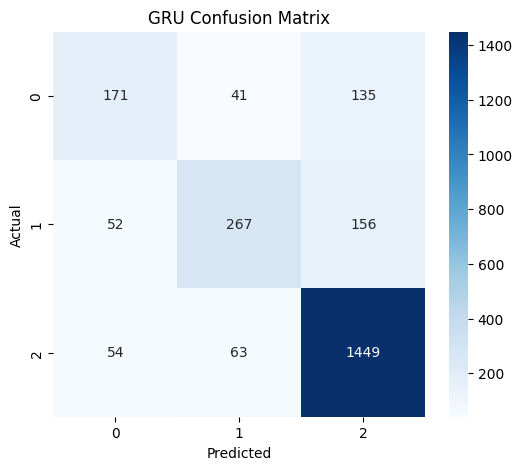

In [12]:
cm = confusion_matrix(y_valid, y_pred_classes)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GRU Confusion Matrix")

plt.show()

In [13]:
model.save("../models/gru/gru_model.keras")

In [14]:
import pickle

with open("../models/tokenizer/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)